# [LAB 07] 5. 독립표본 T-Test
## #01. 준비작업
### 1. 라이브러리 참조

In [1]:
from hossam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame, pivot_table

# 가설 검정 가정에 따른 검정 방법 선택을 위한 라이브러리
from scipy.stats import ttest_ind, mannwhitneyu

# 시각화에 필요한 라이브러리
from statannotations.Annotator import Annotator

📦 아이티윌 이광호 강사가 제작한 라이브러리를 사용중입니다.
📚 자세한 사용 방법은 https://py.hossam.kr 을 참고하세요.
📧 Email: leekh4232@gmail.com
🎬 Youtube: https://www.youtube.com/@hossam-codingclub
📝 Blog: https://blog.hossam.kr/
🔖 Version: 0.5.19


## #02.예제(1)- 지혈제 효과 비교
### 1. 데이터 가져오기
- 두 종류의 지혈제 효과를 측정한 자료이다.
    - 실험 참가자를 두 그룹으로 임의 분할한 후 피부에 작은 상처를 내어 피가 흐르게 한 다음, 한 그룹에는 지혈제 b를 다른 그룹에는 지혈제 g를 투여하여 완전히 지혈될 때 까지의 시간(분)을 측정하였다.
    - 지혈제에 따른 지혈시간이 유의미한 차이가 있는지 확인하라.

In [2]:
df1= load_data('styptic')
df1.head()

📚 실험 참가자를 두 그룹으로 임의 분할한 후 피부에 작은 상처를 내어 피가 흐르게 한 다음, 한 그룹에는 지혈제 B를 다른 그룹에는 지혈제 G를 투여하여 완전히 지혈될 때 까지의 시간(분)을 측정한 두 종료의 지혈제 효과를 측정한 자료 (출처: 방송통신대학교 통계학개론)


,B,G
0,8.800,9.900
1,8.900,10.000
2,8.400,9.000
3,7.900,11.100
4,8.200,9.800


### 2. 시각화를 위한 데이터 재배치
- 두 그룹을 비교하는 시각화를 위해서는 melt 함수를 사용하여 long타입으로 재배치 해야함

In [3]:
df1_melt = melt(df1, var_name='group', value_name='value')
df1_melt.head()

,group,value
0,B,8.800
1,B,8.900
2,B,8.400
3,B,7.900
4,B,8.200


### 3. 데이터 분포 확인

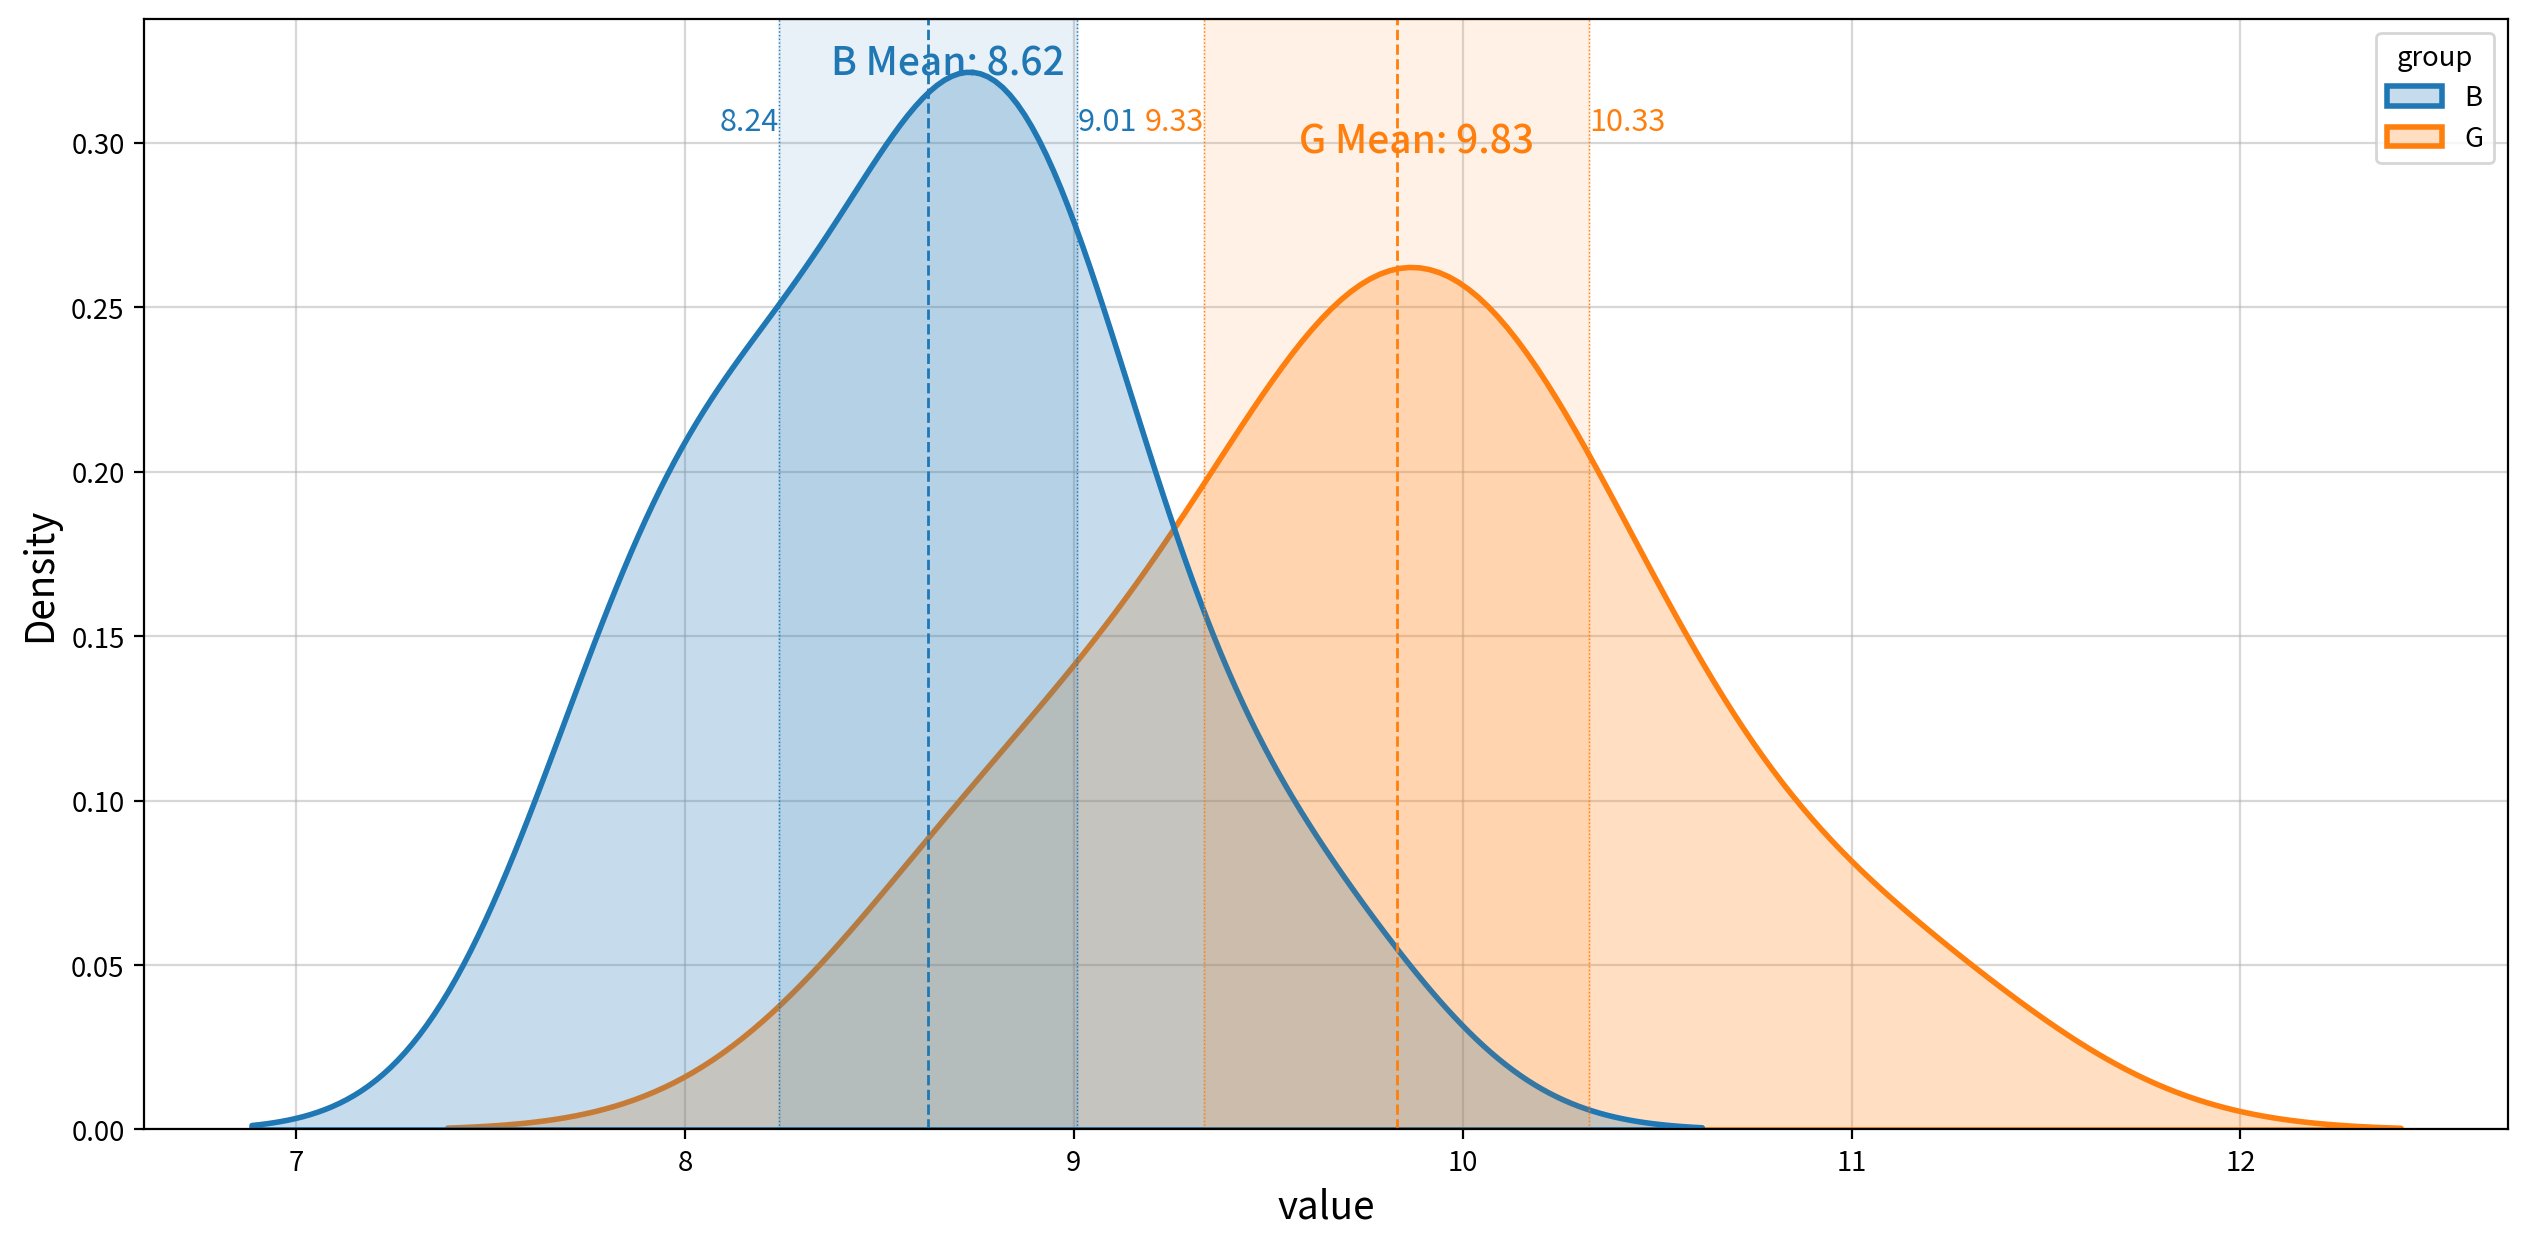

In [4]:
my_plot.kdeplot(df1_melt, x='value', hue='group', fill=True, meanline=True, clevel=0.95)

- 인사이트 
    - 두 그룹의 커널 밀도 함수 그래프의 모양이 정규분포를 띄고 있으며, 두 그룹의 데이터 분포 모양이 서로 비슷하다고 할 수 있다.

### 4. 가설 검정의 가정확인
- 시각화를 통해 정규분포를 확인하더라도 항상 정확한 통계량을 확인하는 것이 좋다.

In [5]:
my_stats.test_assumptions(df1, columns=['B', 'G'])

,test,statistic,p-value,result
field,,,,
B,normaltest,0.083,0.959,True
G,normaltest,0.201,0.904,True
Bartlett,equal_var,0.556,0.456,True


- 모두 정규성과 등분산성을 만족하므로 Student's T-Test를 수행할 수 있다.

### 5. Student's T-Test 양측검정
- Student's T-Test로 두 그룹간의 평균을 비교하기 위해서는 ttest_ind 함수에 등분산성을 의미하는 equal_var=True 파라미터를 적용한다.
    - 정규성은 만족하지만 등분산성을 만족하지 않을 경우 equal_var=False를 적용하여 Welch T-Test를 수행한다.

In [6]:
s,p = ttest_ind(df1['B'], df1['G'], equal_var=True)
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: -4.3497, p-value: 0.0004


- 지혈제B를 사용한 그룹과 지혈제G를 사용한 그룹간 평균 지혈시간에 대해 양측검정을 실시한 결과 통계적으로 유의한 차이를 보였다.(p<0.05)

### 6. Student's T-Test 좌측 단측검정
- B그룹의 평균이 G그룹 평균보다 더 작은지 검정 

In [7]:
s,p = ttest_ind(df1['B'], df1['G'], equal_var=True, alternative='less')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: -4.3497, p-value: 0.0002


- 지혈제B를 사용한 그룹과 지혈제G를 사용한 그룹간 평균 지혈시간에 대해 좌측 단측검정을 실시한 결과 통계적으로 유의하게 작다(p < 0.05)

### 7. Student's T-Test 우측 단측검정
- B그룹의 평균이 G그룹 평균보다 더 작은지 검정 

In [8]:
s,p = ttest_ind(df1['B'], df1['G'], equal_var=True, alternative='greater')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: -4.3497, p-value: 0.9998


- 지혈제B를 사용한 그룹과 지혈제G를 사용한 그룹간 평균 지혈시간에 대해 우측 단측검정을 실시한 결과 통계적으로 유의하게 크지 않다(p > 0.05)

### 8. 가설검정 시각화

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. G: t-test independent samples, P_val:3.862e-04 t=-4.350e+00


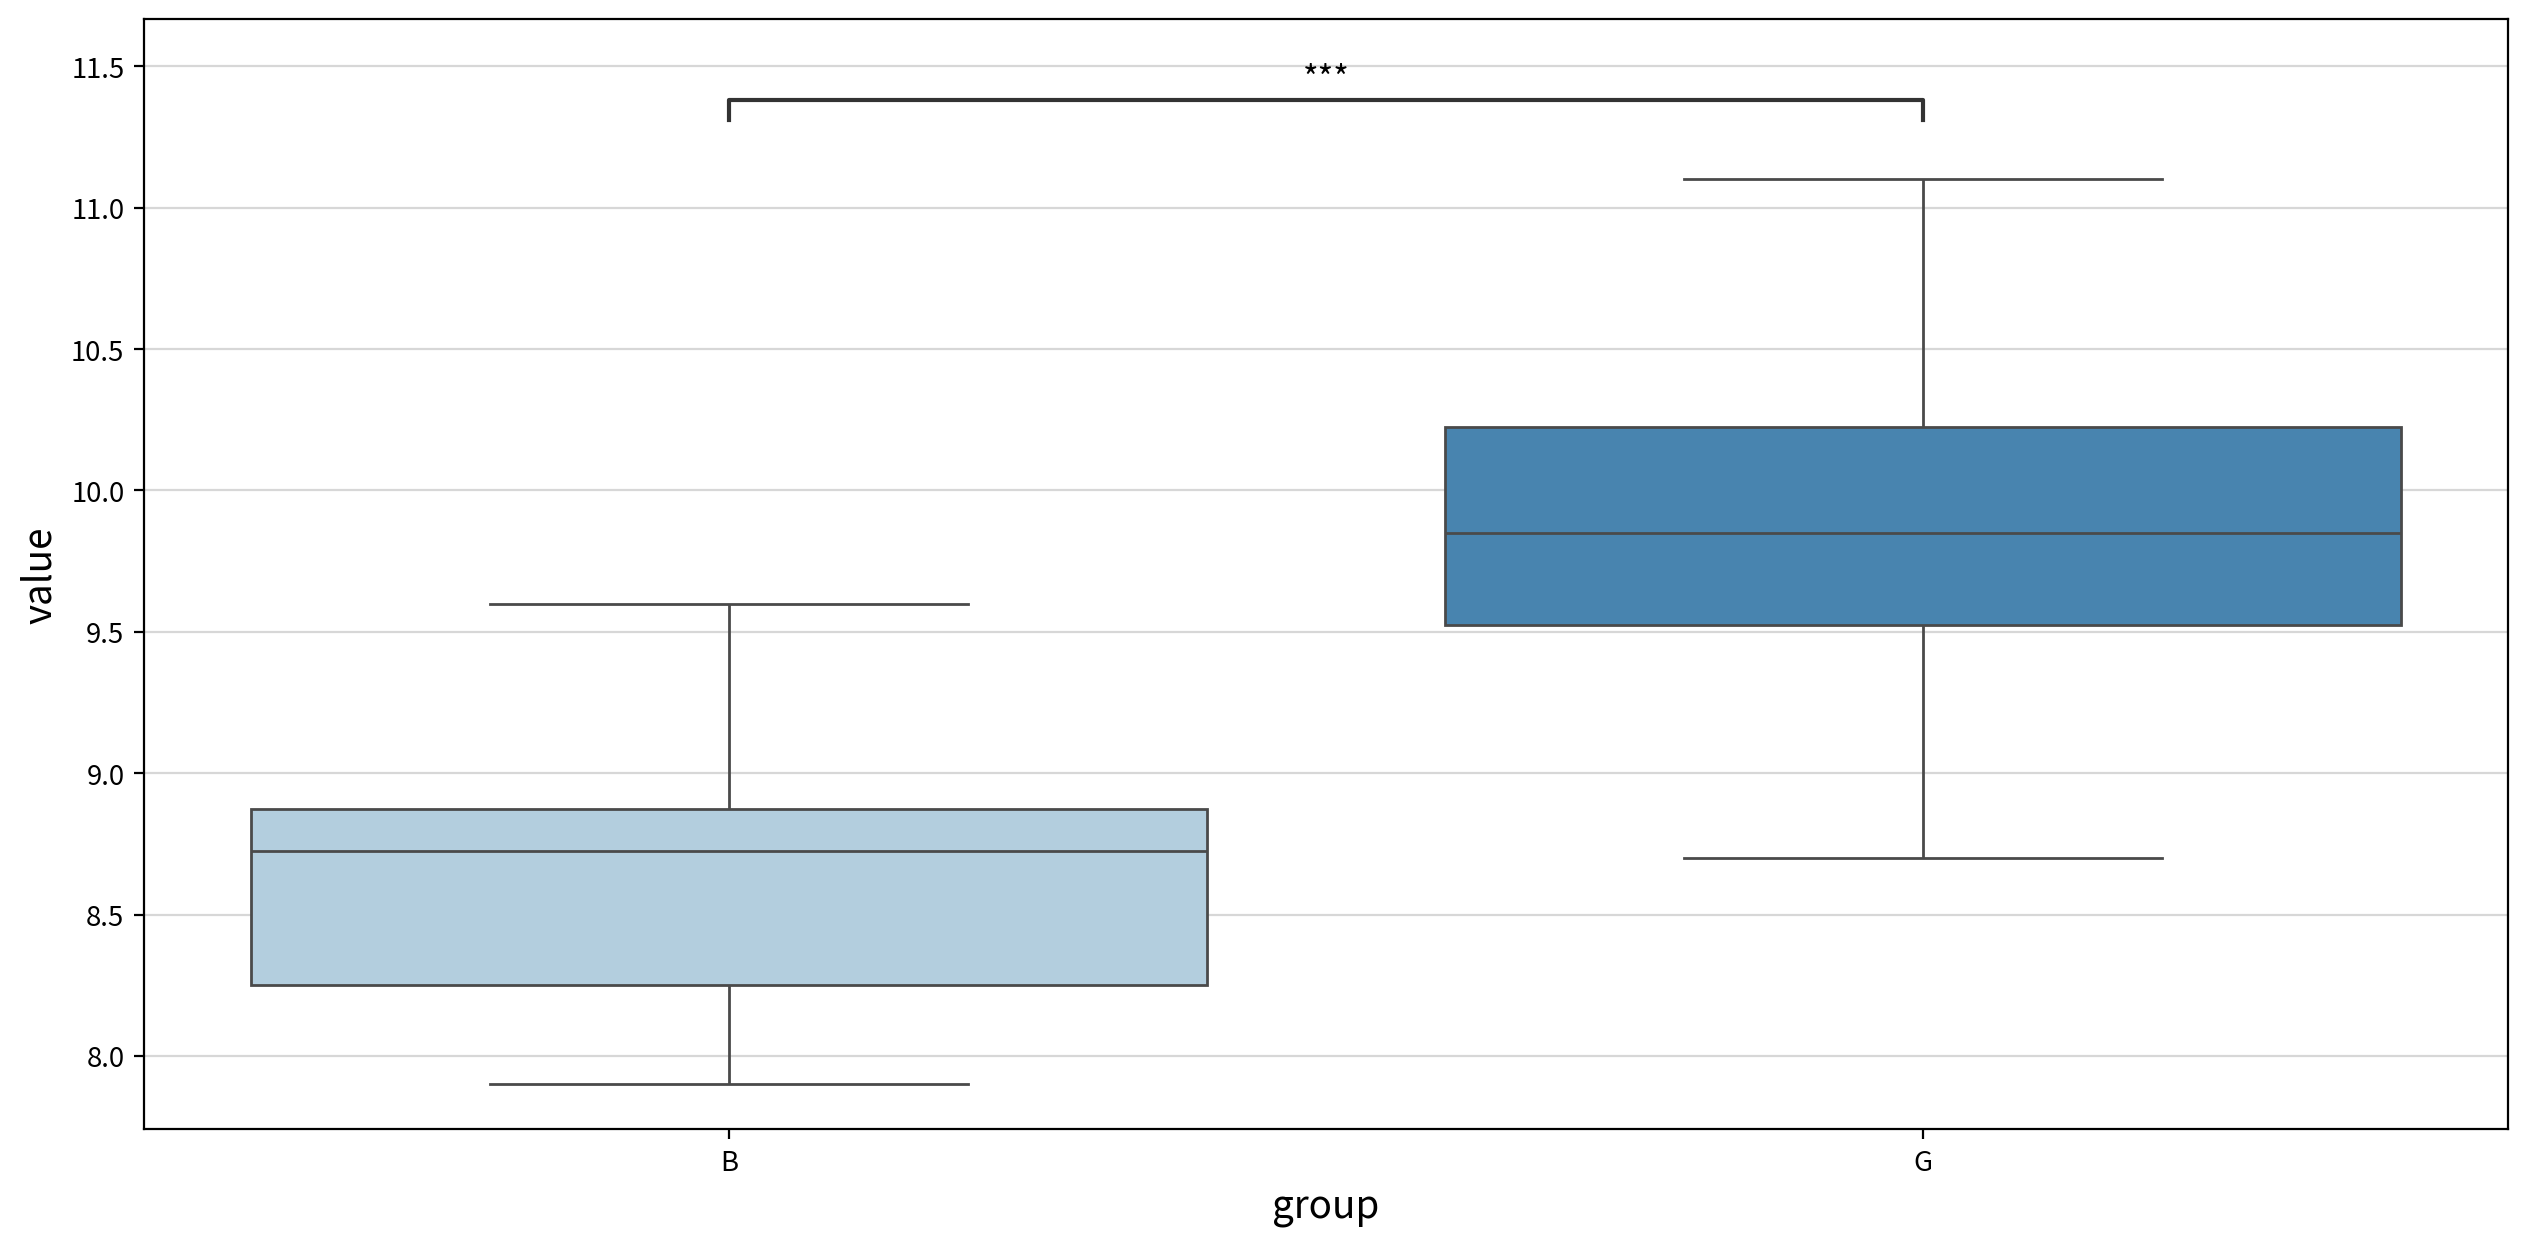

In [9]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df1_melt, x='group', y='value', hue='group', palette='Blues', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(data=df1_melt,              #데이터프레임
                      x='group',                  # x축 변수
                      y='value',                 # y축 변수
                      pairs=[('B','G')], #비교할 그룹 쌍
                      ax=ax)                      # 그래프 축

# 가설검정 알고리즘 종류
annotator.configure(test='t-test_ind')
annotator.apply_and_annotate()

my_plot.show()


## #03. 예제(2)- 인공심장 효과 측정
### 1. 데이터 가져오기
- 자료는 두 독립적인 그룹의 심장병 환자에 대한 심장계수를 측정한 것이다.
    - 그룹1은 심장수술을 받고 부착한 인공장기의 기능이 정상적인 사람들이고, 그룹2는 비정상으로 판명된 사람들이다.
    - 이 두 그룹의 환자에게 부착한 인공장기의 기능에 따라 심장계수가 서로 차이가 나는지 알고 싶은 것이 이 실험의 목적이다.

In [10]:
df2=load_data('heatrate')
df2.head()

📚 두 독립적인 그룹의 심장병 환자에 대한 심장계수(cardiac index)를 측정한 데이터. `그룹1`은 심장수술을 받고 부착한 인공장기의 기능이 정상적인 사람들이고, `그룹2`는 비정상으로 판명된 사람들이다.심장계수는 수술 직후에 측정하였다. (출처: 방송통신대학교 통계학개론)


,그룹1,그룹2
0,3.840,3.970
1,2.600,2.500
2,1.190,2.700
3,2.000,3.360
4,6.200,3.550


### 2. 시각화를 위한 재배치(wide 타입 -> long 타입)

In [11]:
df2_melt = melt(df2, var_name='group', value_name='value')
df2_melt.head()

,group,value
0,그룹1,3.840
1,그룹1,2.600
2,그룹1,1.190
3,그룹1,2.000
4,그룹1,6.200


### 3. 데이터 분포 확인

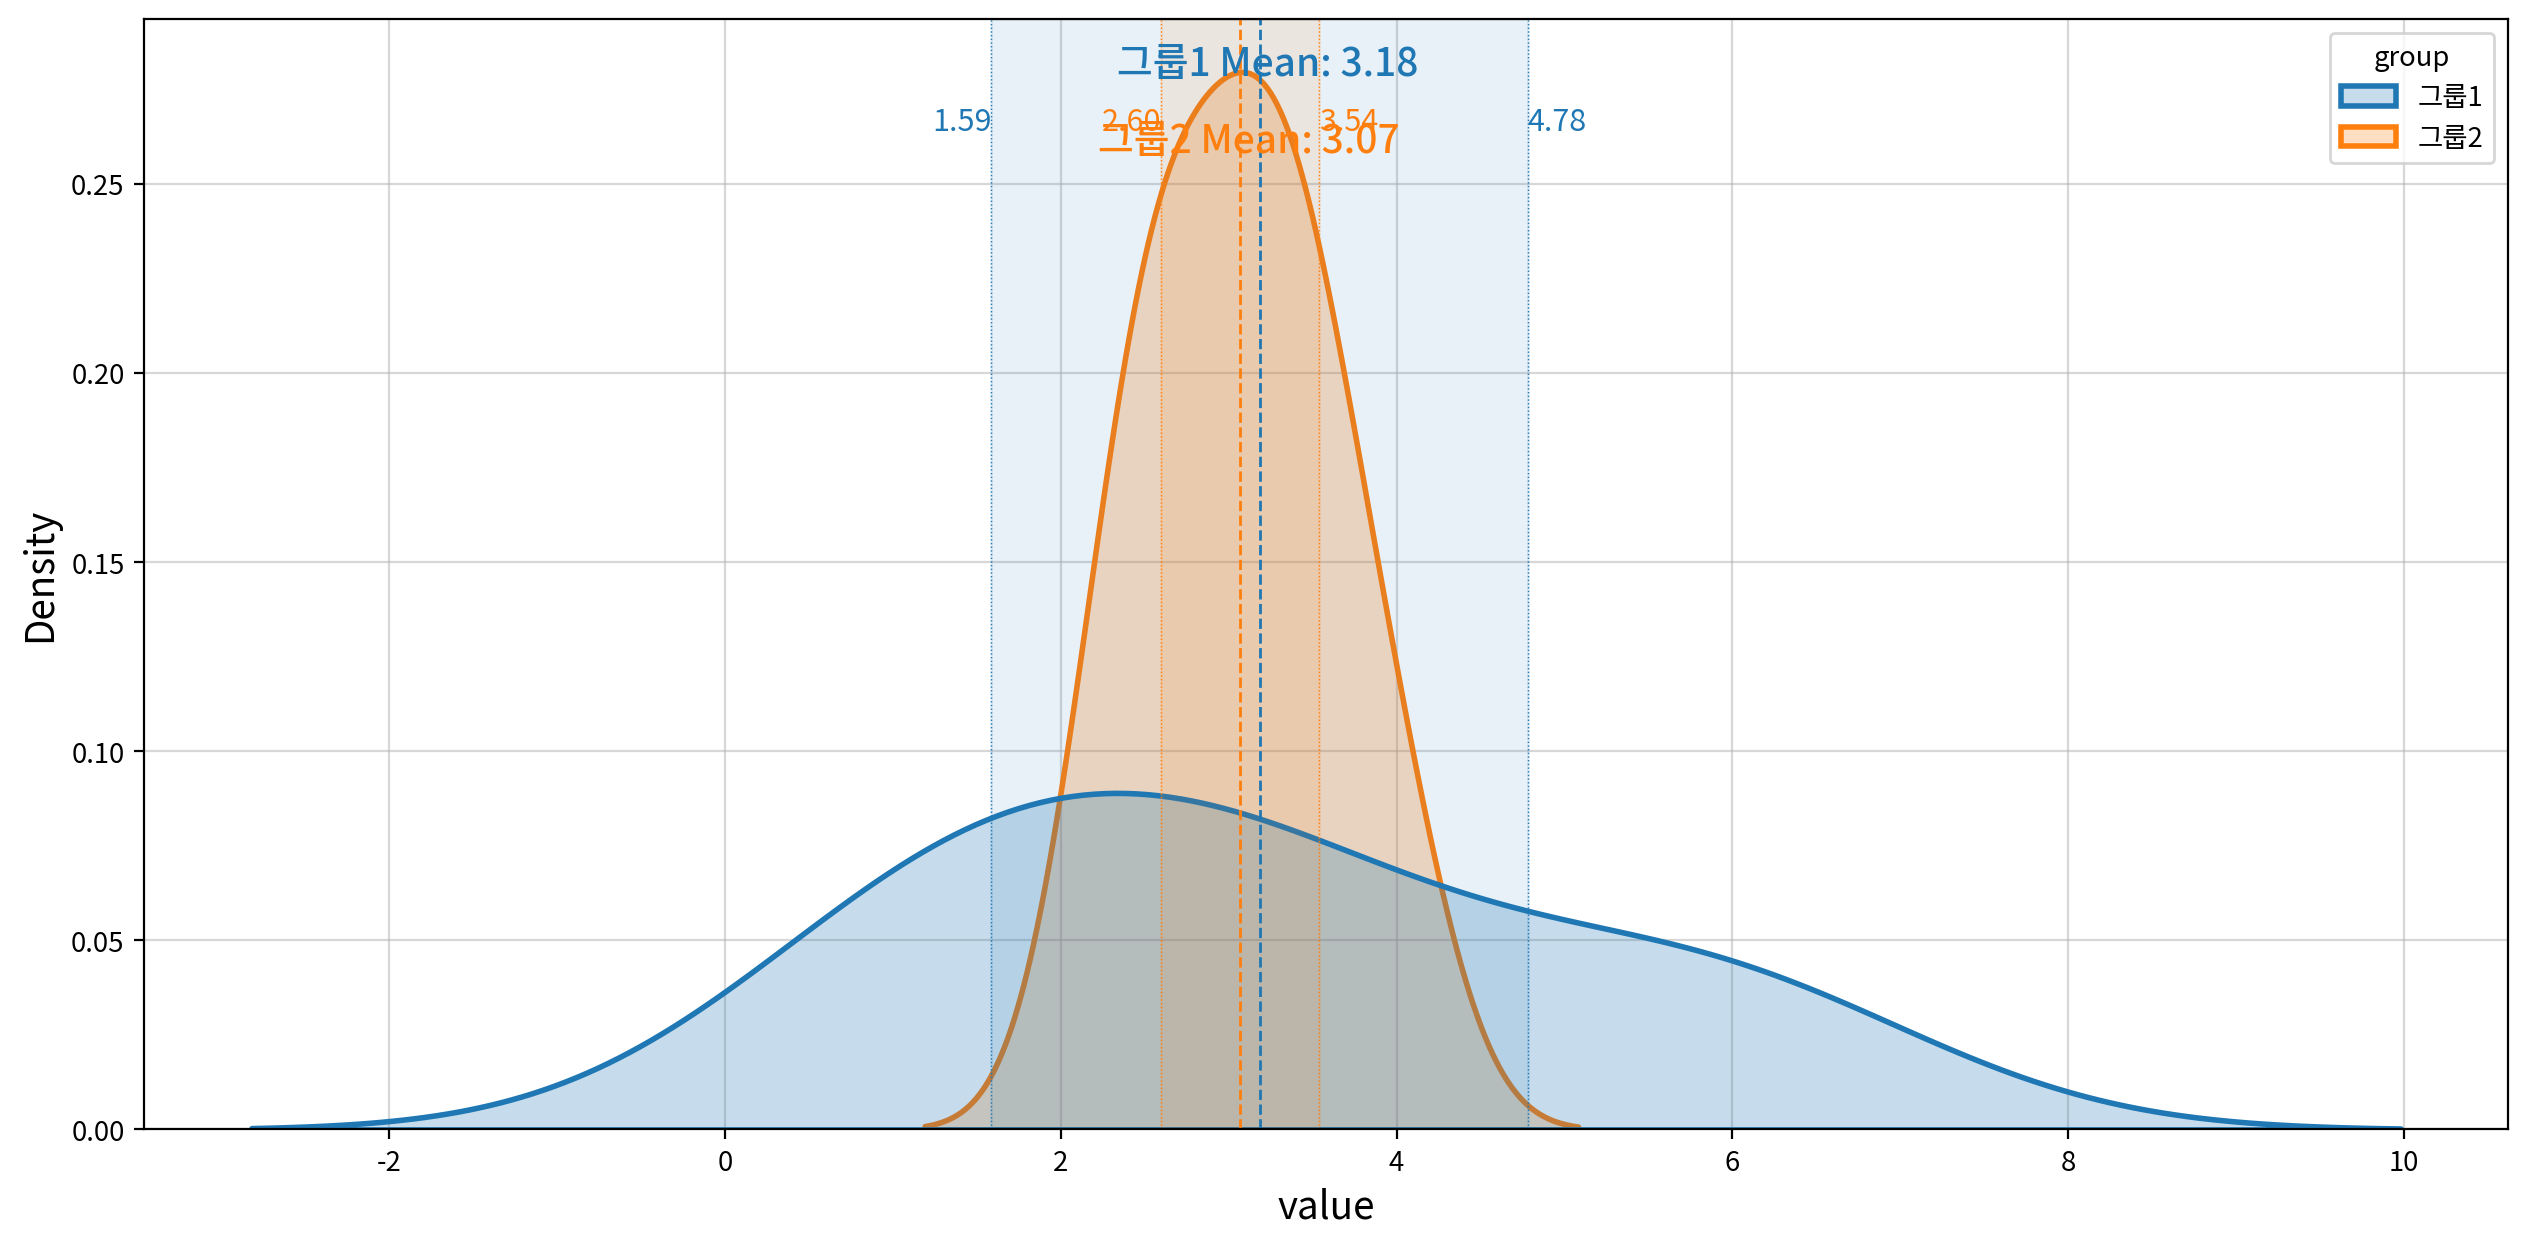

In [12]:
my_plot.kdeplot(df2_melt, x='value', hue='group', fill=True, meanline=True, clevel=0.95)

- 인사이트
    - 그룹2의 경우 정규분포 모양을 띄고 있지만 그룹1의 경우는 정규분포인지 확실치 않다.
    - 또한 두 그룹의 퍼짐 정도가 다르기 때문에 등분산성을 충족한다고 볼 수 없다.

### 4. 가설검정의 가정 확인

In [13]:
my_stats.test_assumptions(df2, columns=['그룹1', '그룹2'])

,test,statistic,p-value,result
field,,,,
그룹1,normaltest,0.840,0.657,True
그룹2,normaltest,0.261,0.878,True
Bartlett,equal_var,8.029,0.005,False


- 정규성은 만족하지만 등분산성을 만족하지는 않기 때문에 Welch T-Test를 수행해야 한다.

### 5. Welch T-Test 양측 검정
- 두 그룹간 심장계수의 차이가 있는지를 검정
- 데이터의 등분산성이 만족되지 않을 경우 equal_var 파라미터에 False를 설정하여 Welch's T-Test를 수행한다.

In [14]:
s,p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False)
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 0.1633, p-value: 0.8742


- 두 그룹의 심장계수에 대해 양측검정을 실시한 결과 통계적으로 유의한 차이를 보이지 않았다(p>=0.05)

### 6. Welch T-Test 좌측 단측검정
- 그룹1의 심장계수가 그룹2의 심장계수보다 작은지 검정

In [15]:
s,p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False, alternative='less')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 0.1633, p-value: 0.5629


- 두 그룹의 심장계수에 대해 좌측 단측검정을 실시한 결과 통계적으로 유의하게 작지 않다(p>=0.05)

### 7. Welch T-Test 우측 단측검정
- 그룹1의 심장계수가 그룹2의 심장계수보다 큰지 검정

In [16]:
s,p = ttest_ind(df2['그룹1'], df2['그룹2'], equal_var=False, alternative='greater')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 0.1633, p-value: 0.4371


- 두 그룹의 심장계수에 대해 우측 단측검정을 실시한 결과 통계적으로 유의하게 크지 않다.(p>=0.05)

### 8. 가설검정 시각화

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹1 vs. 그룹2: Welch's t-test independent samples, P_val:8.742e-01 t=1.633e-01


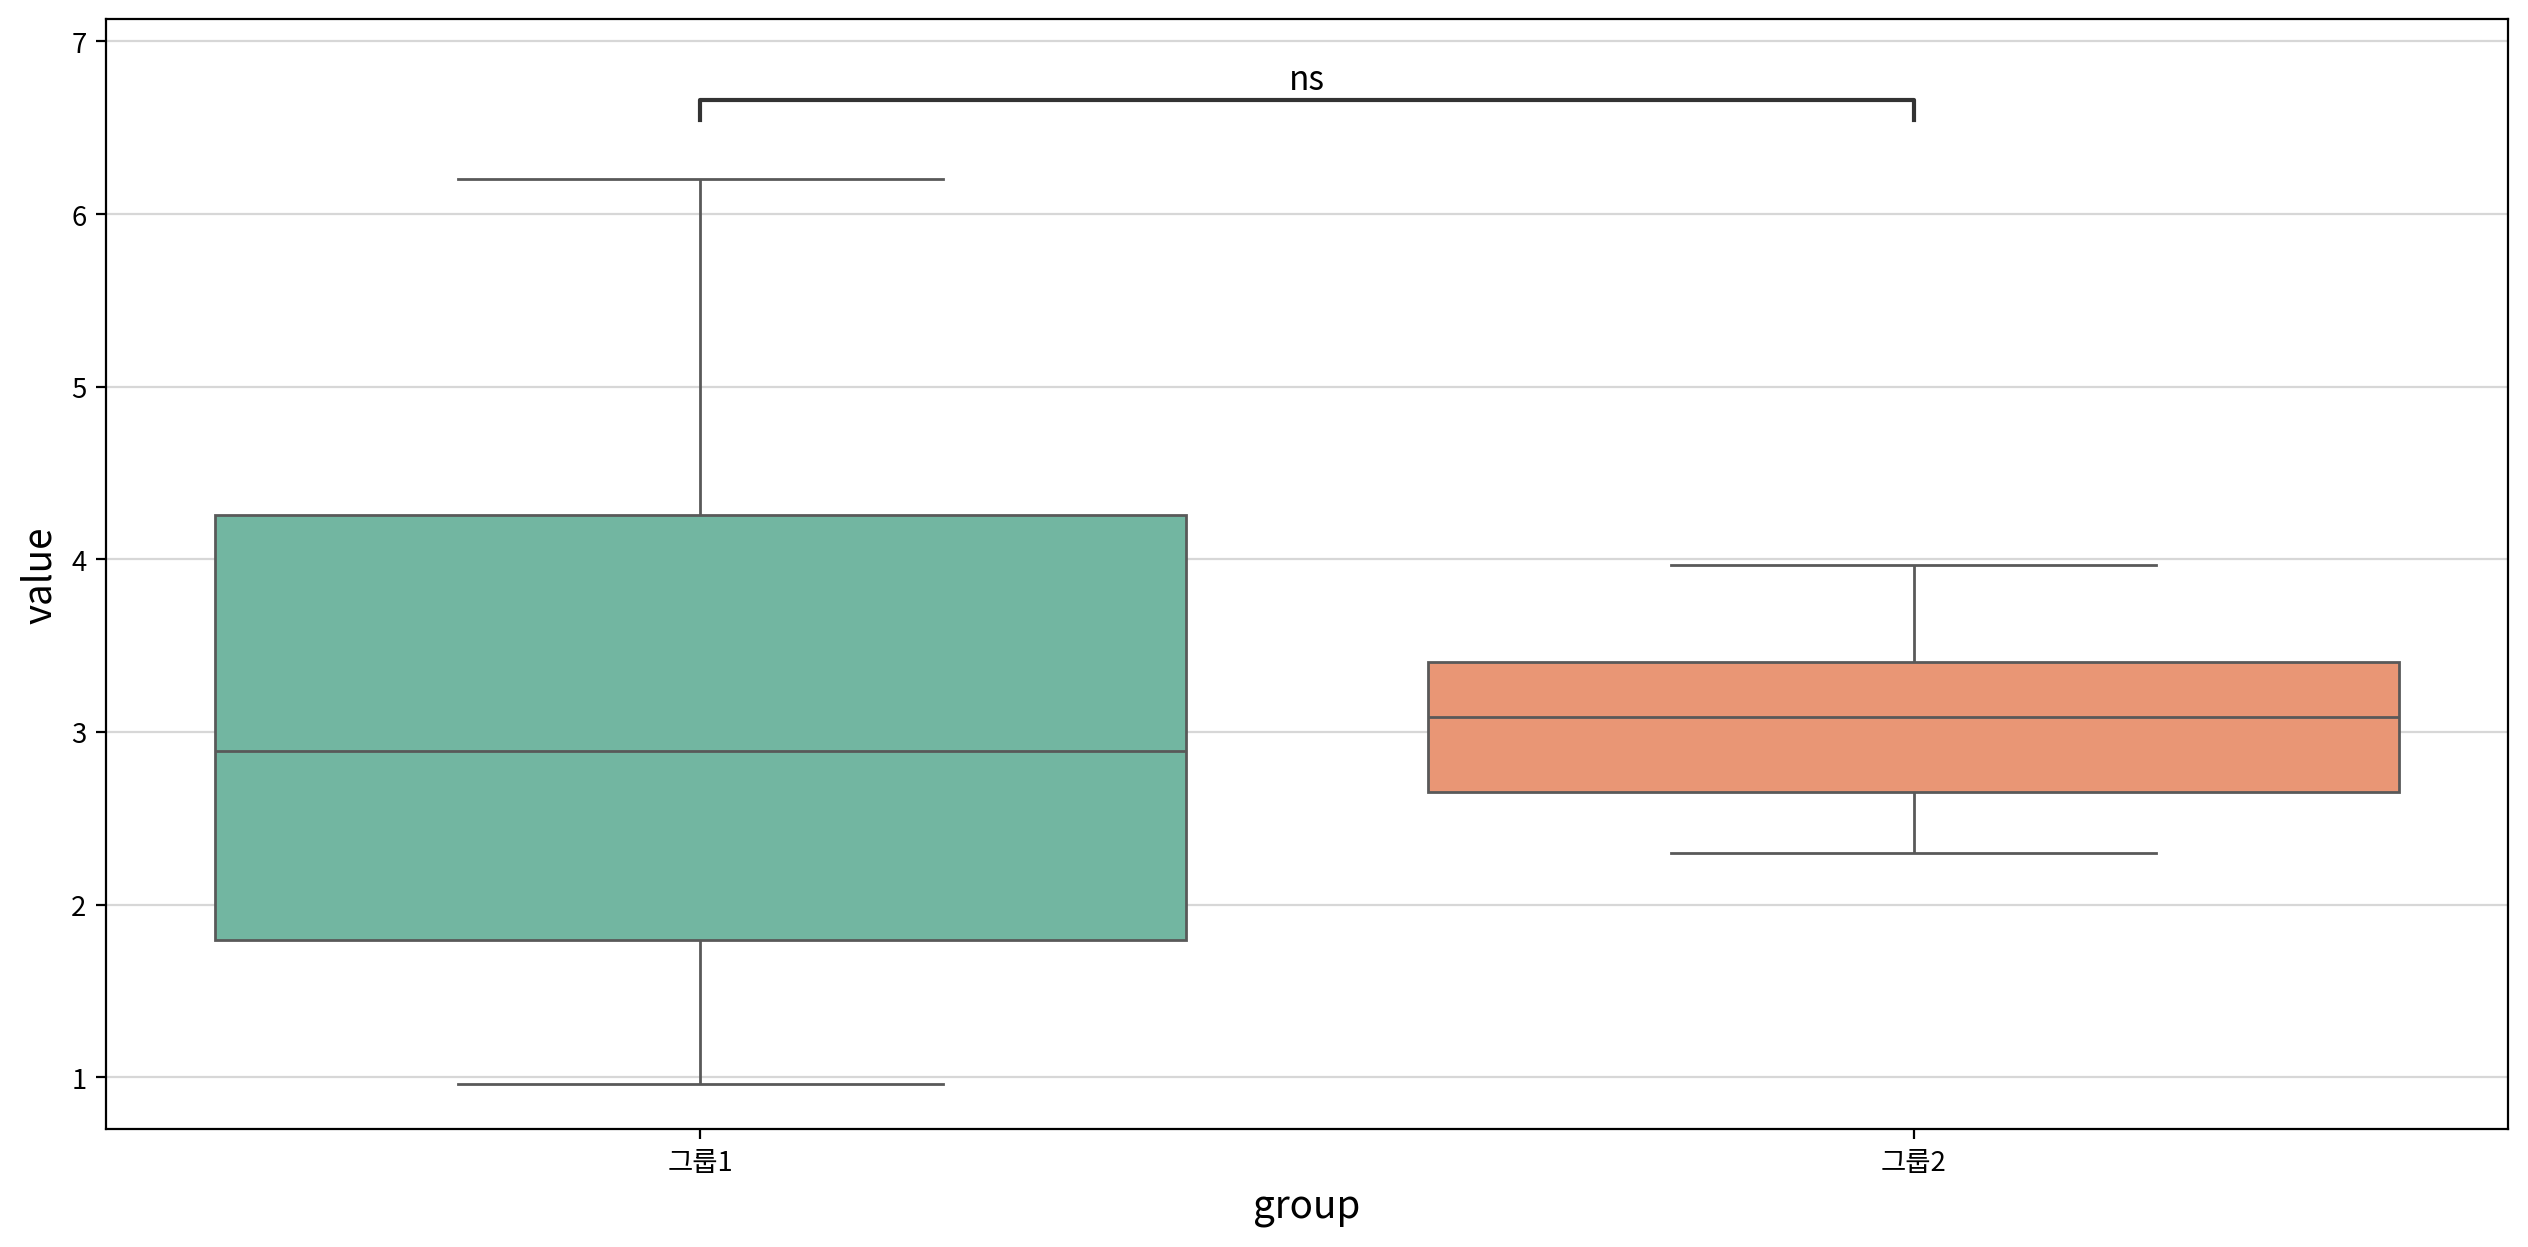

In [17]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df2_melt, x='group', y='value', hue='group', palette='Set2', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(ax, data=df2_melt,              #데이터프레임
                      x='group',                  # x축 변수
                      y='value',                 # y축 변수
                      pairs=[('그룹1','그룹2')], #비교할 그룹 쌍
                      )                      # 그래프 축

# 가설검정 알고리즘 종류
annotator.configure(test='t-test_welch')
annotator.apply_and_annotate()

my_plot.show()


## #03. 예제(3)- 두 종류의 진통제 효과 비교
### 1. 데이터 가져오기

In [18]:
df3 = load_data('analgesic')
df3

📚 두 종류의 진통제(약물A, 약물B)를 투여한 후 통증이 완화되기까지 걸린 시간(분)을 측정한 가상의 자료.


,group,value
0,약물A,17.300
1,약물A,12.600
2,약물A,18.600
3,약물A,28.800
4,약물A,12.000
5,약물A,12.000
6,약물A,29.700
7,약물A,19.800
8,약물A,10.600
9,약물A,17.700


### 2. 데이터 분포 확인
- 주어진 데이터가 long 타입이므로 전처리 없이 바로 시각화 한다.

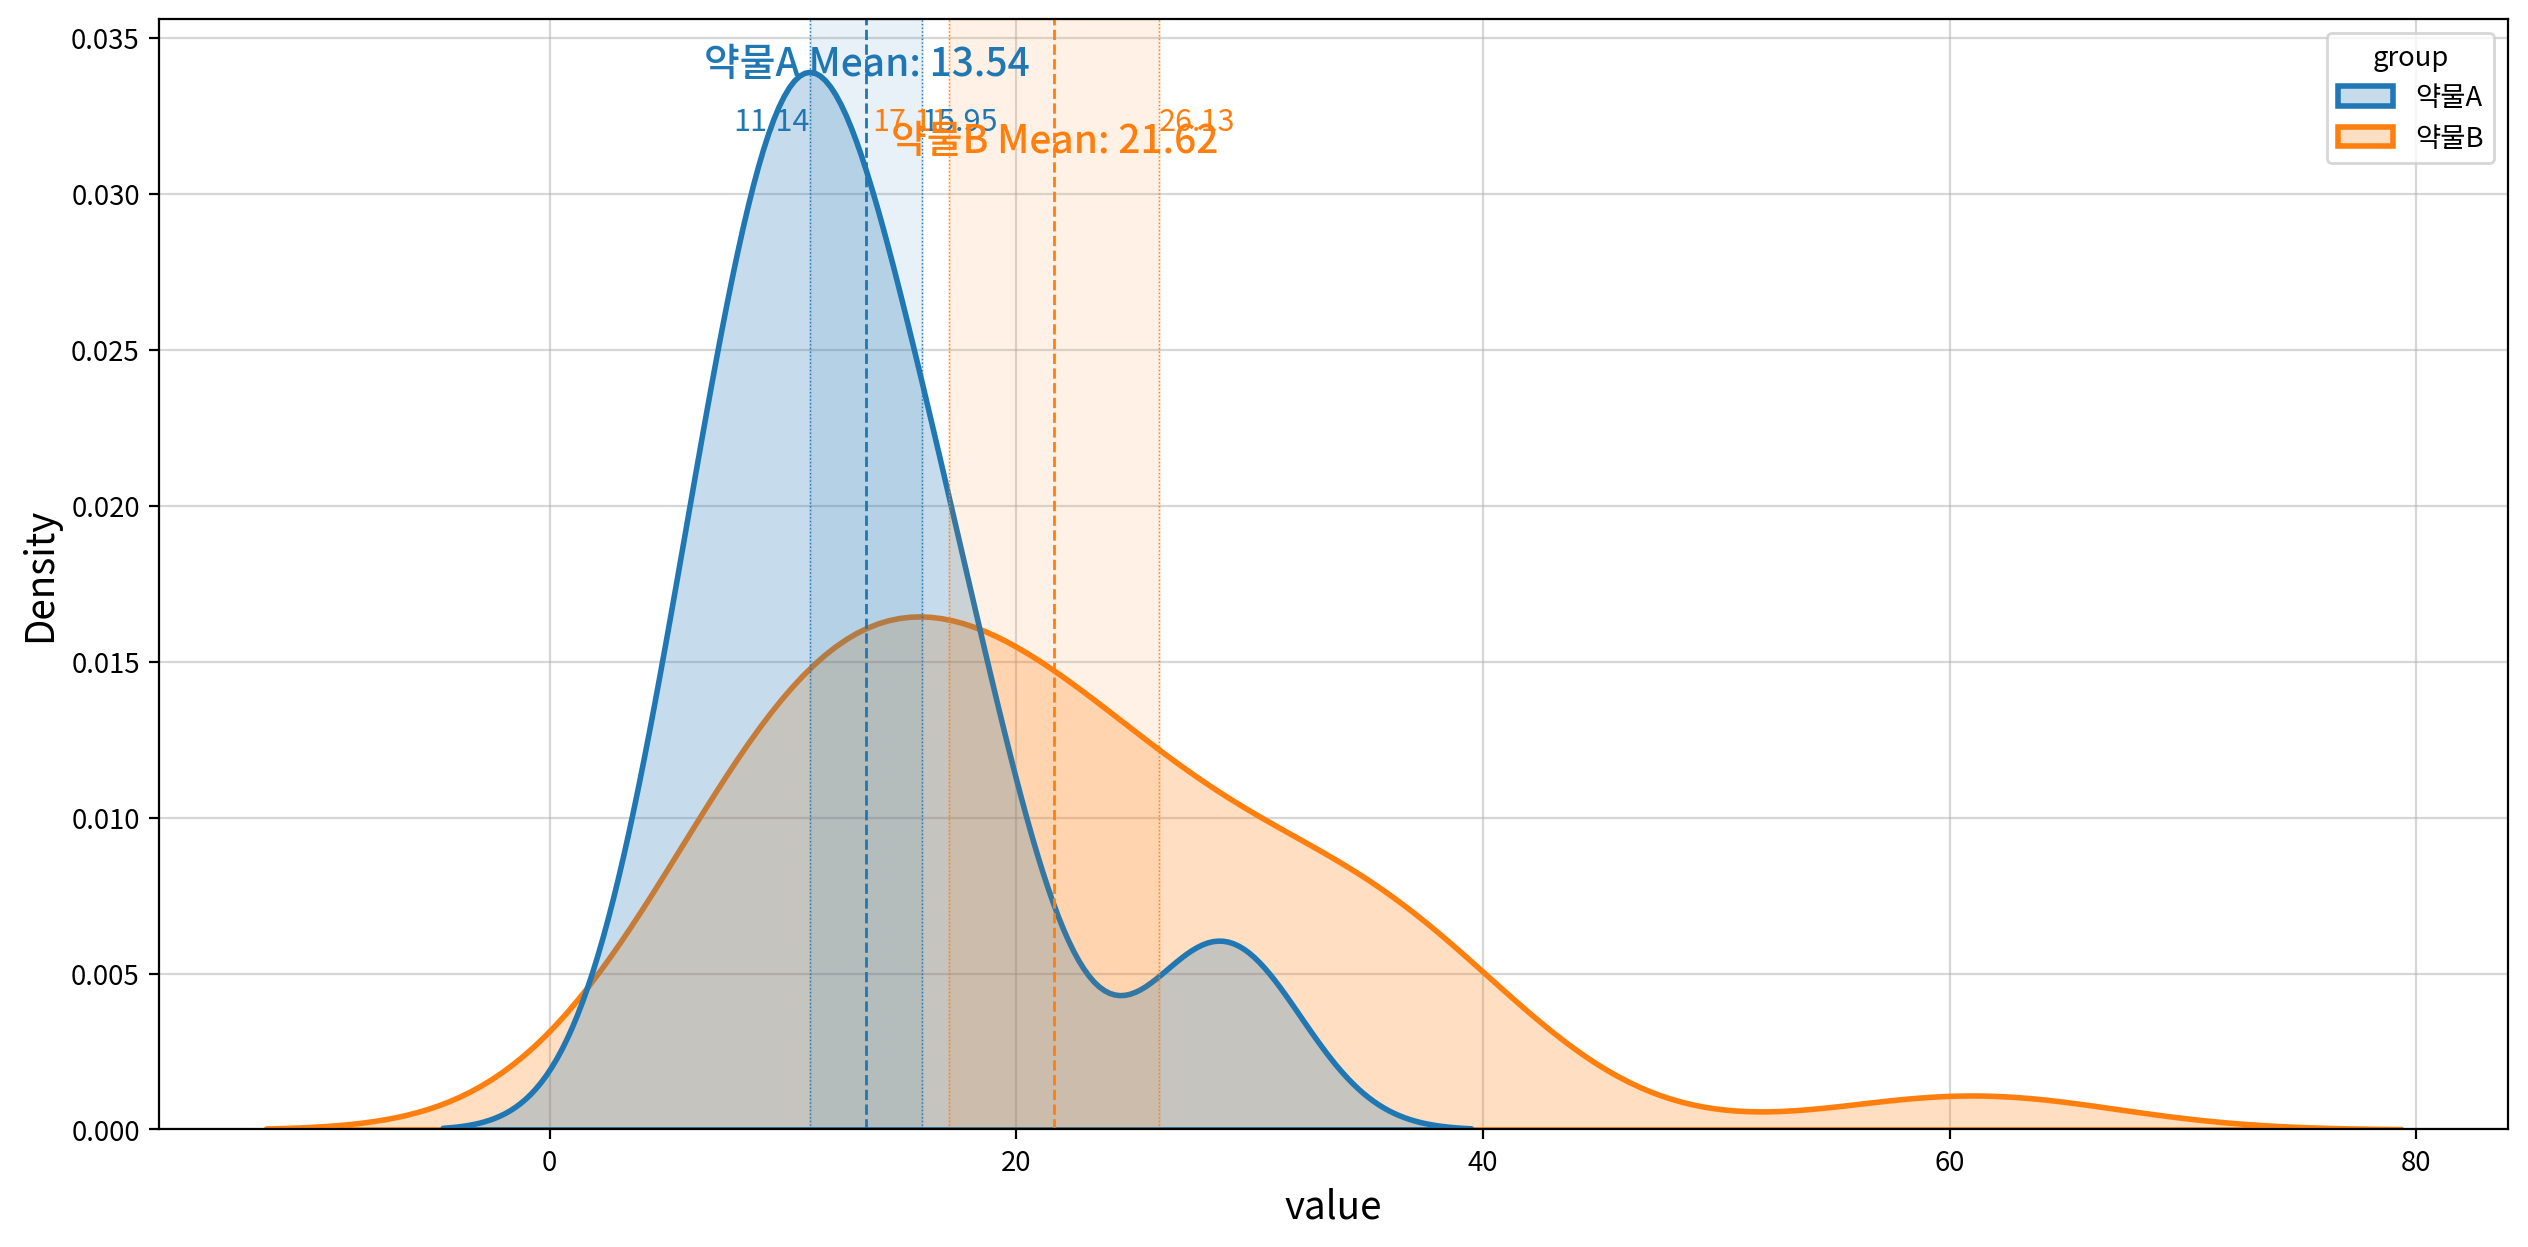

In [19]:
my_plot.kdeplot(df3, x='value', hue='group', fill=True, meanline=True, clevel=0.95)

- 인사이트
    - 두 그룹 모두 오른쪽 꼬리가 관측되고 두 그룹의 분산도 서로 다르다.

### 3. long 타입을 wide 타입으로 재배치(1) - 그룹별 일련번호 생성
- groupby에 대한 cumcount() 함수는 그룹별로 일련번호를 생성한다ㅣ.

In [20]:
df3_group = df3.copy()
df3_group['idx'] = df3_group.groupby('group').cumcount()
df3_group

,group,value,idx
0,약물A,17.300,0
1,약물A,12.600,1
2,약물A,18.600,2
3,약물A,28.800,3
4,약물A,12.000,4
5,약물A,12.000,5
6,약물A,29.700,6
7,약물A,19.800,7
8,약물A,10.600,8
9,약물A,17.700,9


### 4. long 타입을 wide 타입으로 재배치(2) - pivot_table 구성
- 생성한 일련번호를 인덱스로, 범주형 변수를 컬럼으로 재배치한 pivot_table을 구성한다.

In [21]:
df3_pivot = pivot_table(df3_group, index='idx', columns='group', values='value')
df3_pivot.head()

group,약물A,약물B
idx,,
0,17.300,14.000
1,12.600,61.000
2,18.600,19.900
3,28.800,10.600
4,12.000,32.900


### 5. 가설검정의 가정 확인

In [22]:
my_stats.test_assumptions(df3_pivot)

,test,statistic,p-value,result
field,,,,
약물A,normaltest,9.191,0.010,False
약물B,normaltest,11.884,0.003,False
Levene,equal_var,7.304,0.009,False


- 정규성을 충족하지 않기 때문에 등분산성 충족 여부와 상관 없이 Mann-Whitney U 검정을 수행해야 한다.

### 5. Mann-Whitney U 양측검정

In [23]:
s,p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'])
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 249.0000, p-value: 0.0030


- 약물A와 약물B가 각각 통증 완화에 걸리는 시간에 대해 양측검정을 실시간 결과 두 약물간의 효과는 통계적으로 유의한 차이가 있다. (p<0.05)

### 6. Mann-Whitney U 좌측 단측검정

In [24]:
s,p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'], alternative='less')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 249.0000, p-value: 0.0015


- 약물A와 약물B가 각각 통증 완화에 걸리는 시간에 대해 좌측 단측검정을 실시한 결과 약물A가 진통완화에 걸리는 시간이 통계적으로 유의하게 짧았다. (p<0.05)

### 7. Mann-Whitney U 우측 단측검정

In [25]:
s,p = mannwhitneyu(df3_pivot['약물A'], df3_pivot['약물B'], alternative='greater')
print(f'statistic: {s:.4f}, p-value: {p:.4f}')

statistic: 249.0000, p-value: 0.9986


- 약물A와 약물B가 각각 통증 완화에 걸리는 시간에 대해 우측 단측검정을 실시한 결과 약물A가 진통완화에 걸리는 시간이 통계적으로 유의하게 길지않았다. (p>=0.05)

### 8. 가설검정 시각화

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


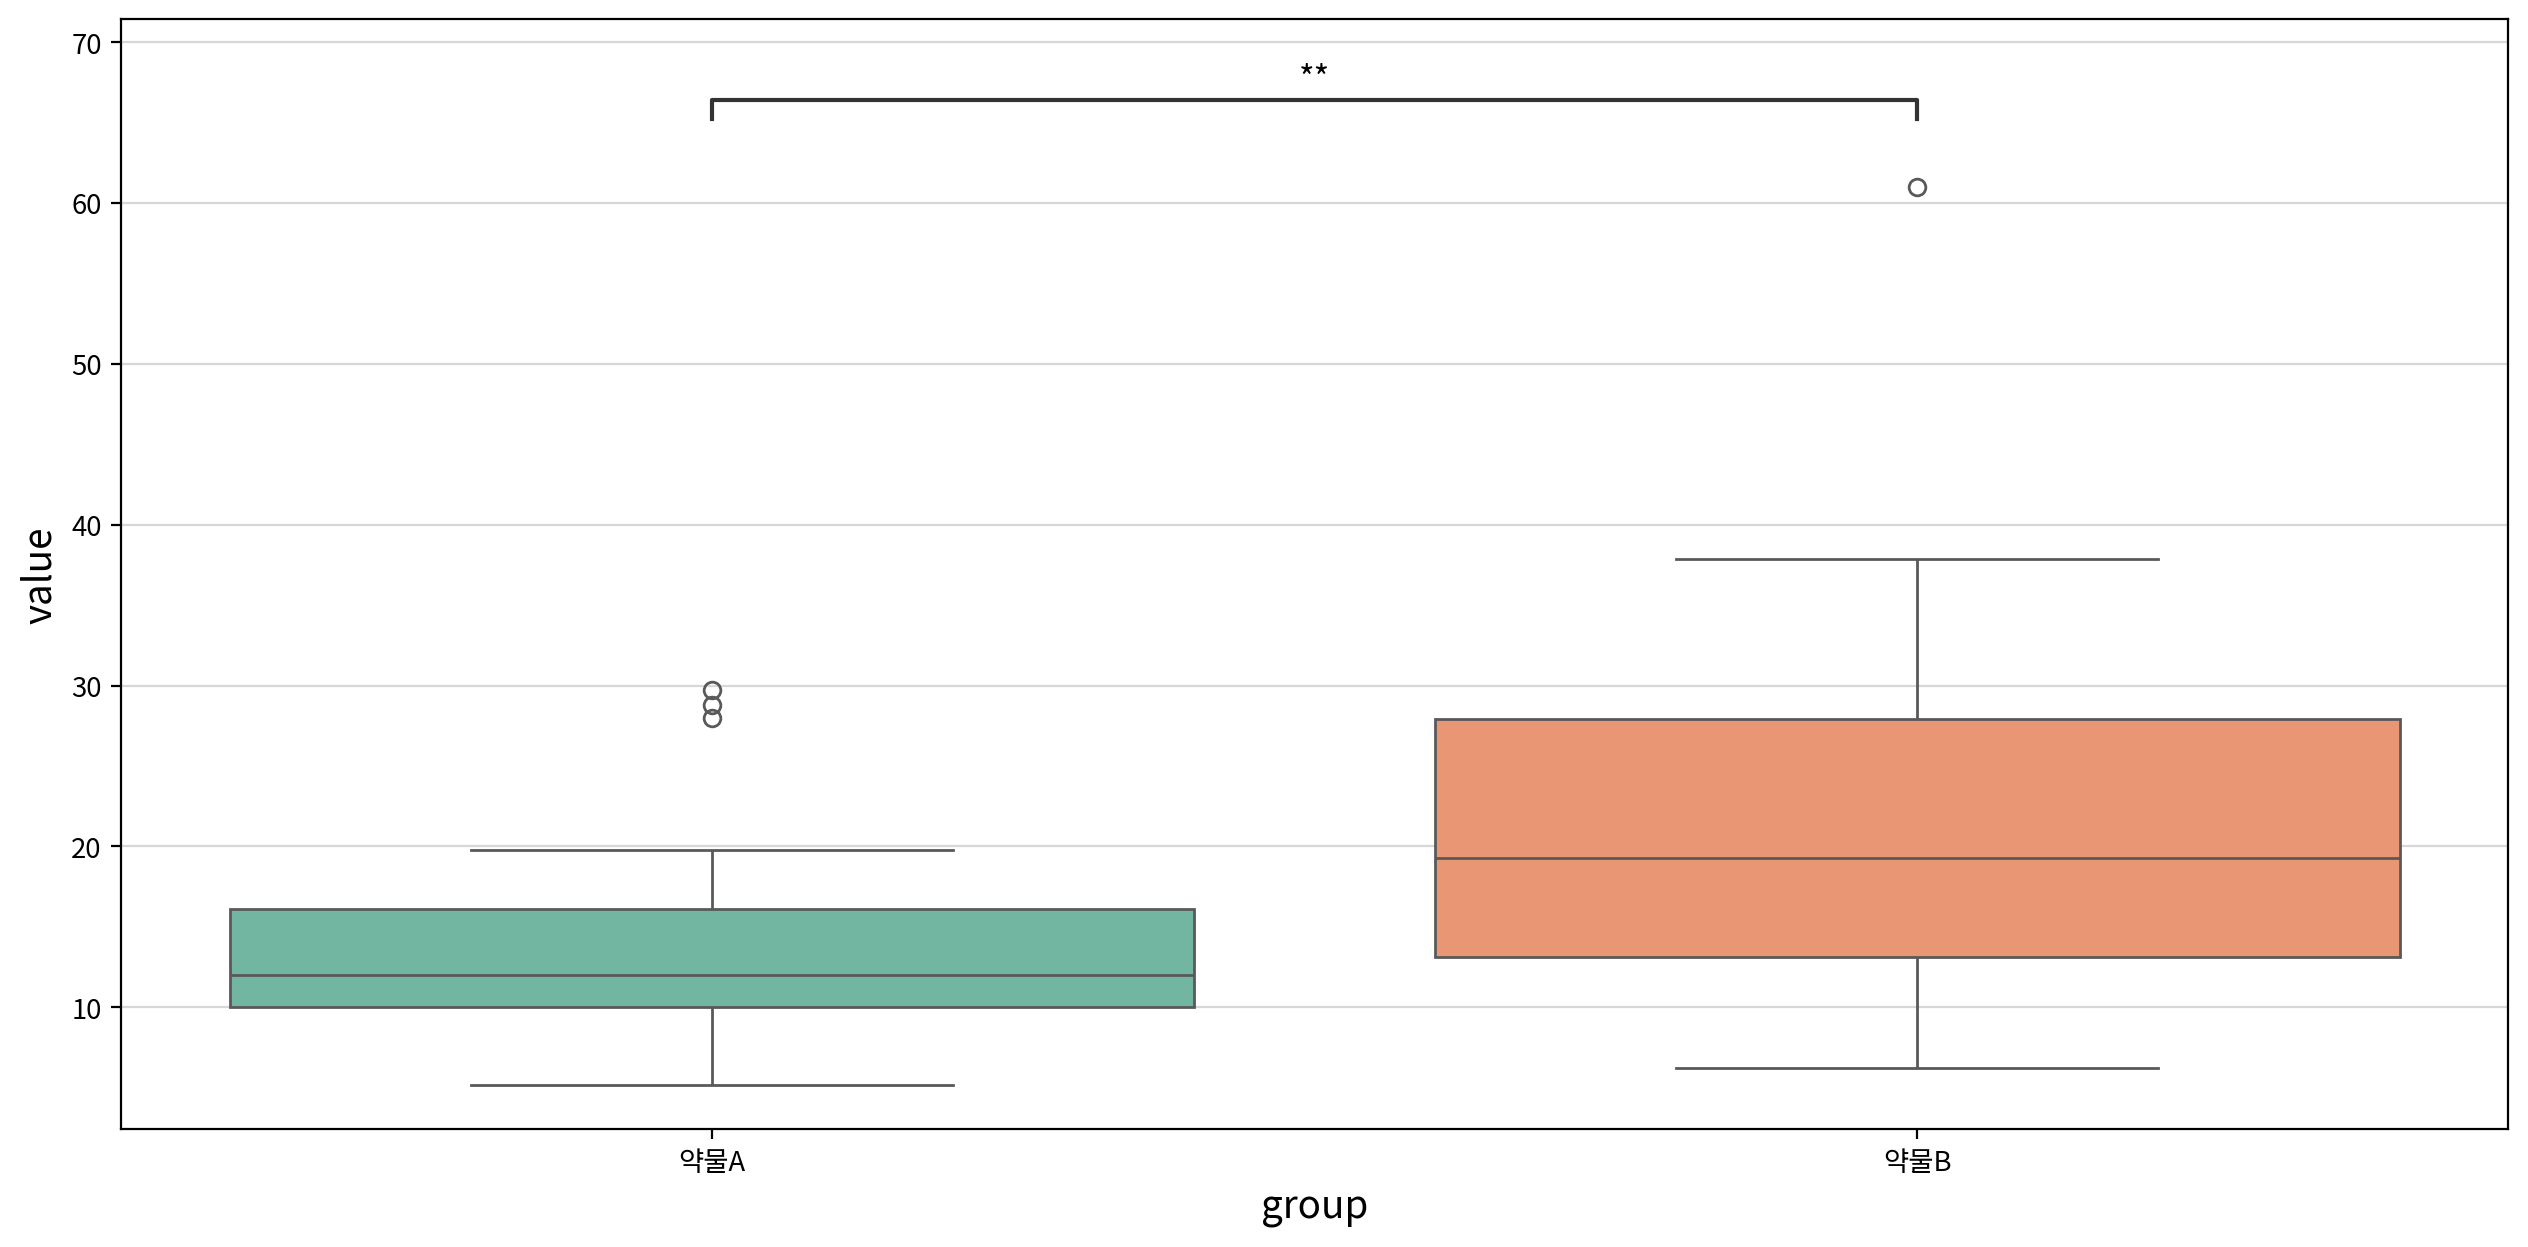

In [26]:
fig, ax = my_plot.init()
my_plot.boxplot(data=df3, x='group', y='value', hue='group', palette='Set2', ax=ax)

# 독립표본 T검정 결과를 시각화에 추가
annotator = Annotator(ax, data=df3,              #데이터프레임
                      x='group',                  # x축 변수
                      y='value',                 # y축 변수
                      pairs=[('약물A','약물B')], #비교할 그룹 쌍
                      )                      # 그래프 축

# 가설검정 알고리즘 종류
#-> 양측검정 : Mann-Whitney, 좌측단측검정 : Mann-Whitney-lt, 우측단측검정: 좌측단측검정 : Mann-Whitney-rt
annotator.configure(test='Mann-Whitney')
annotator.apply_and_annotate()

my_plot.show()


## #05. 모듈화 기능확인
### 1. 지혈제 효과 비교

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

B vs. G: t-test independent samples, P_val:3.862e-04 t=-4.350e+00


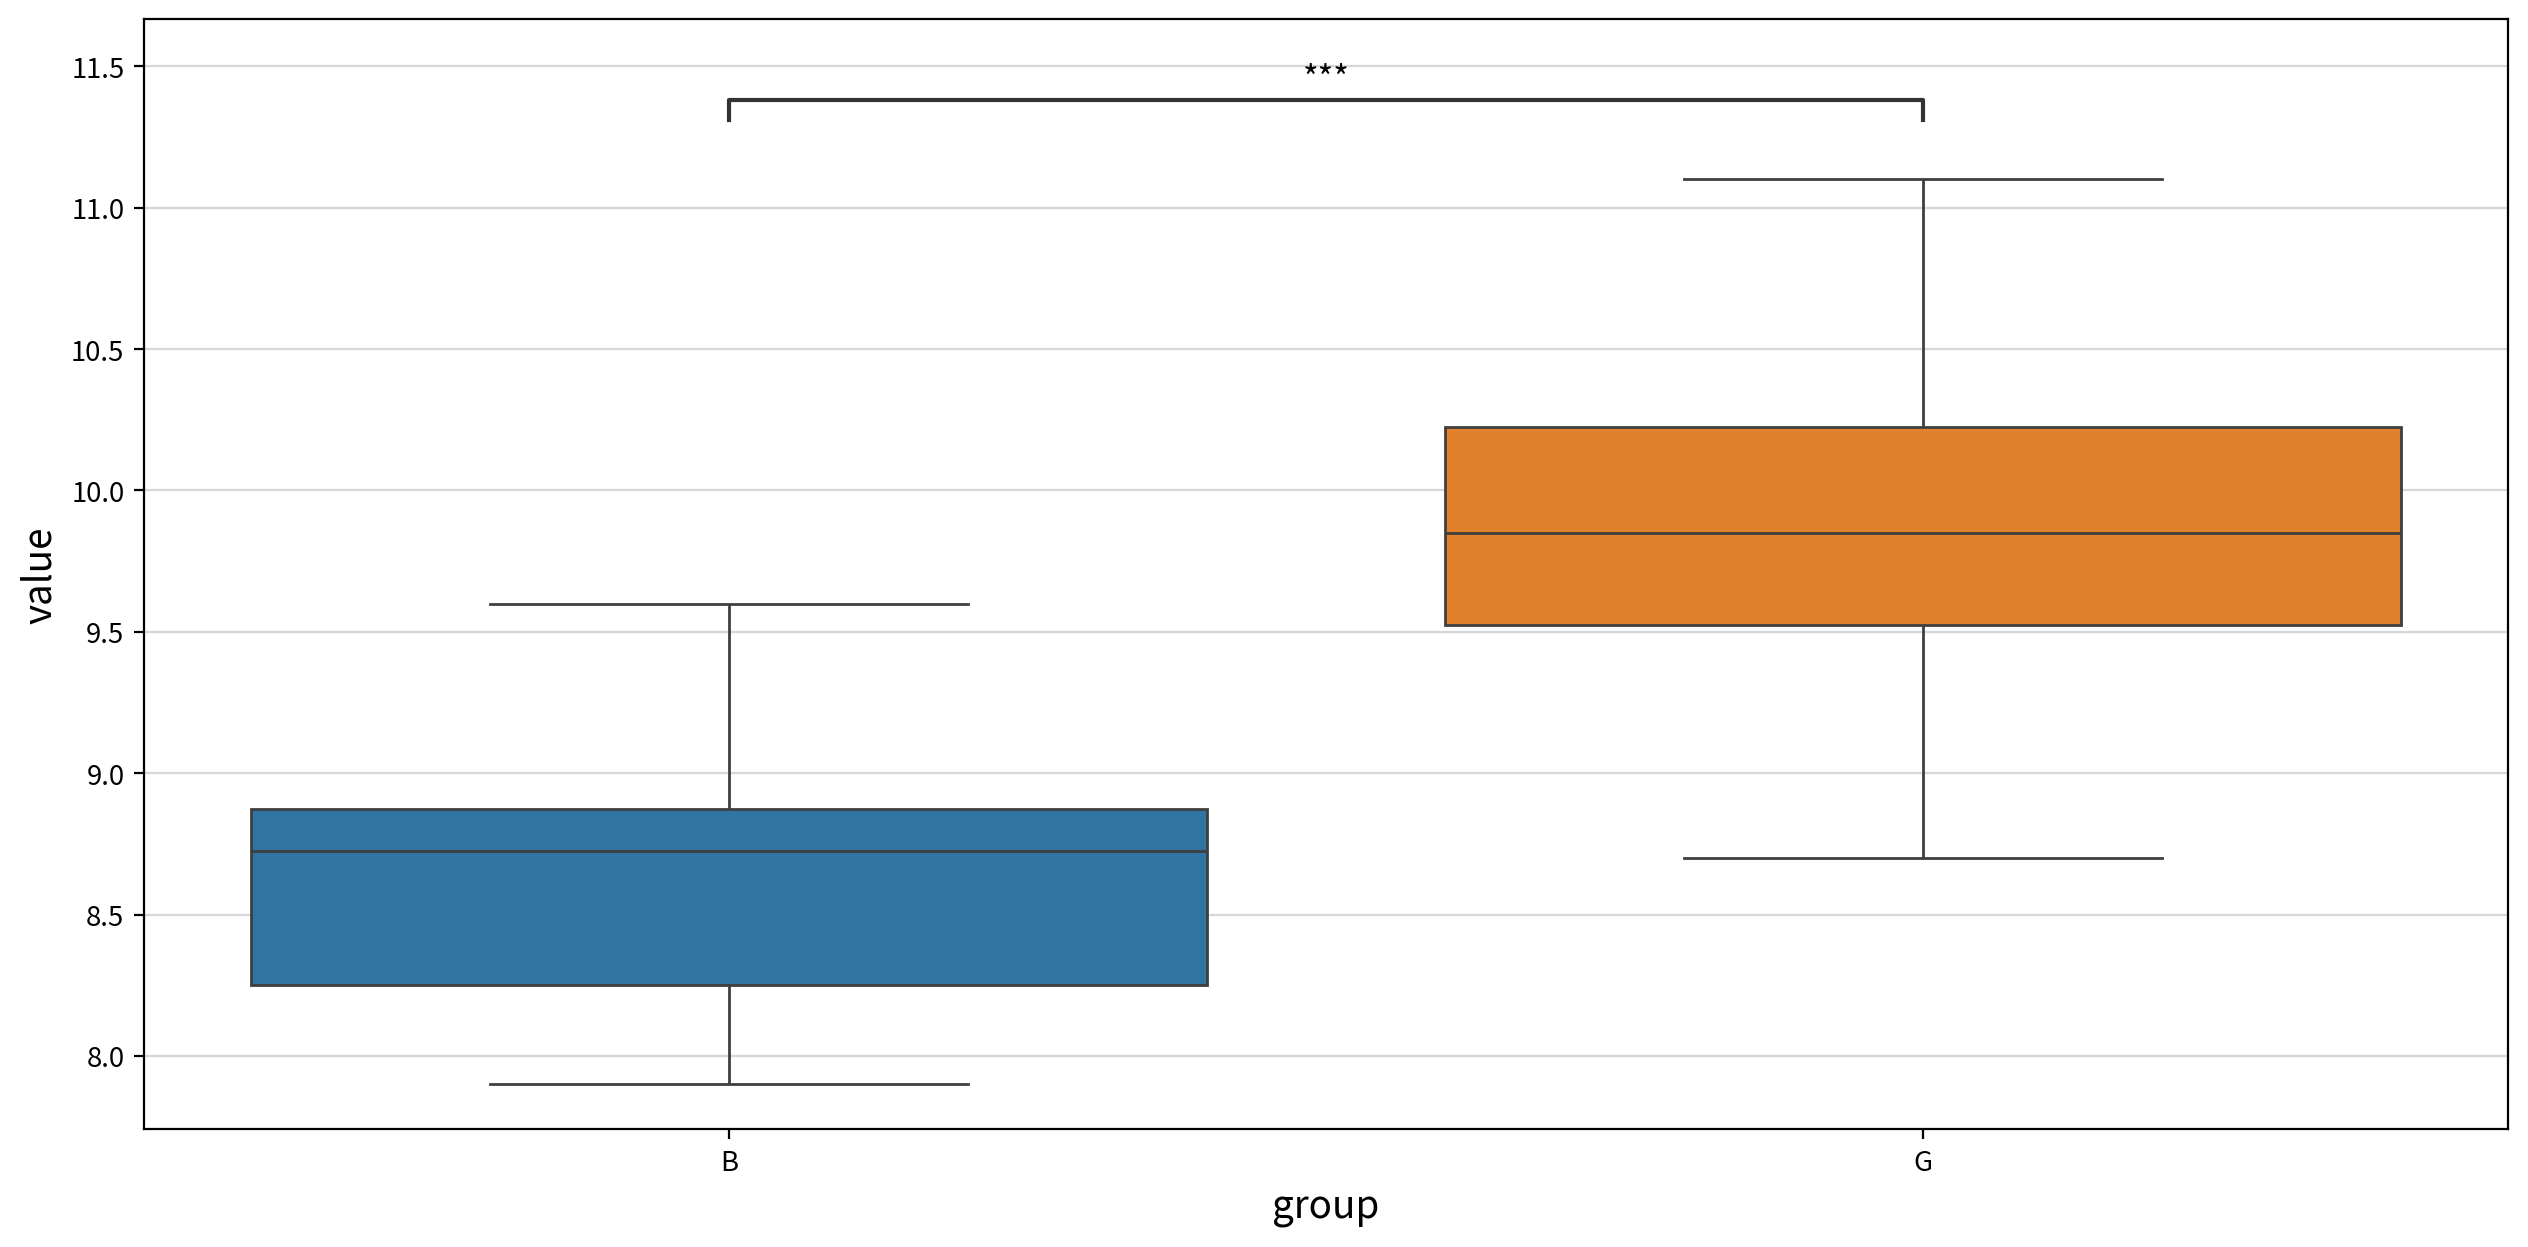

statistic  p-value  significant result
test           alternative                                        
Student t-test two-sided       -4.350    0.000         True  B ≠ G
               less            -4.350    0.000         True  B < G
               greater         -4.350    1.000        False  B ≤ G

In [27]:
my_stats.test_independent(df1, "B", "G")

### 2. 인공심장 효과 측정

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

그룹1 vs. 그룹2: Welch's t-test independent samples, P_val:8.742e-01 t=1.633e-01


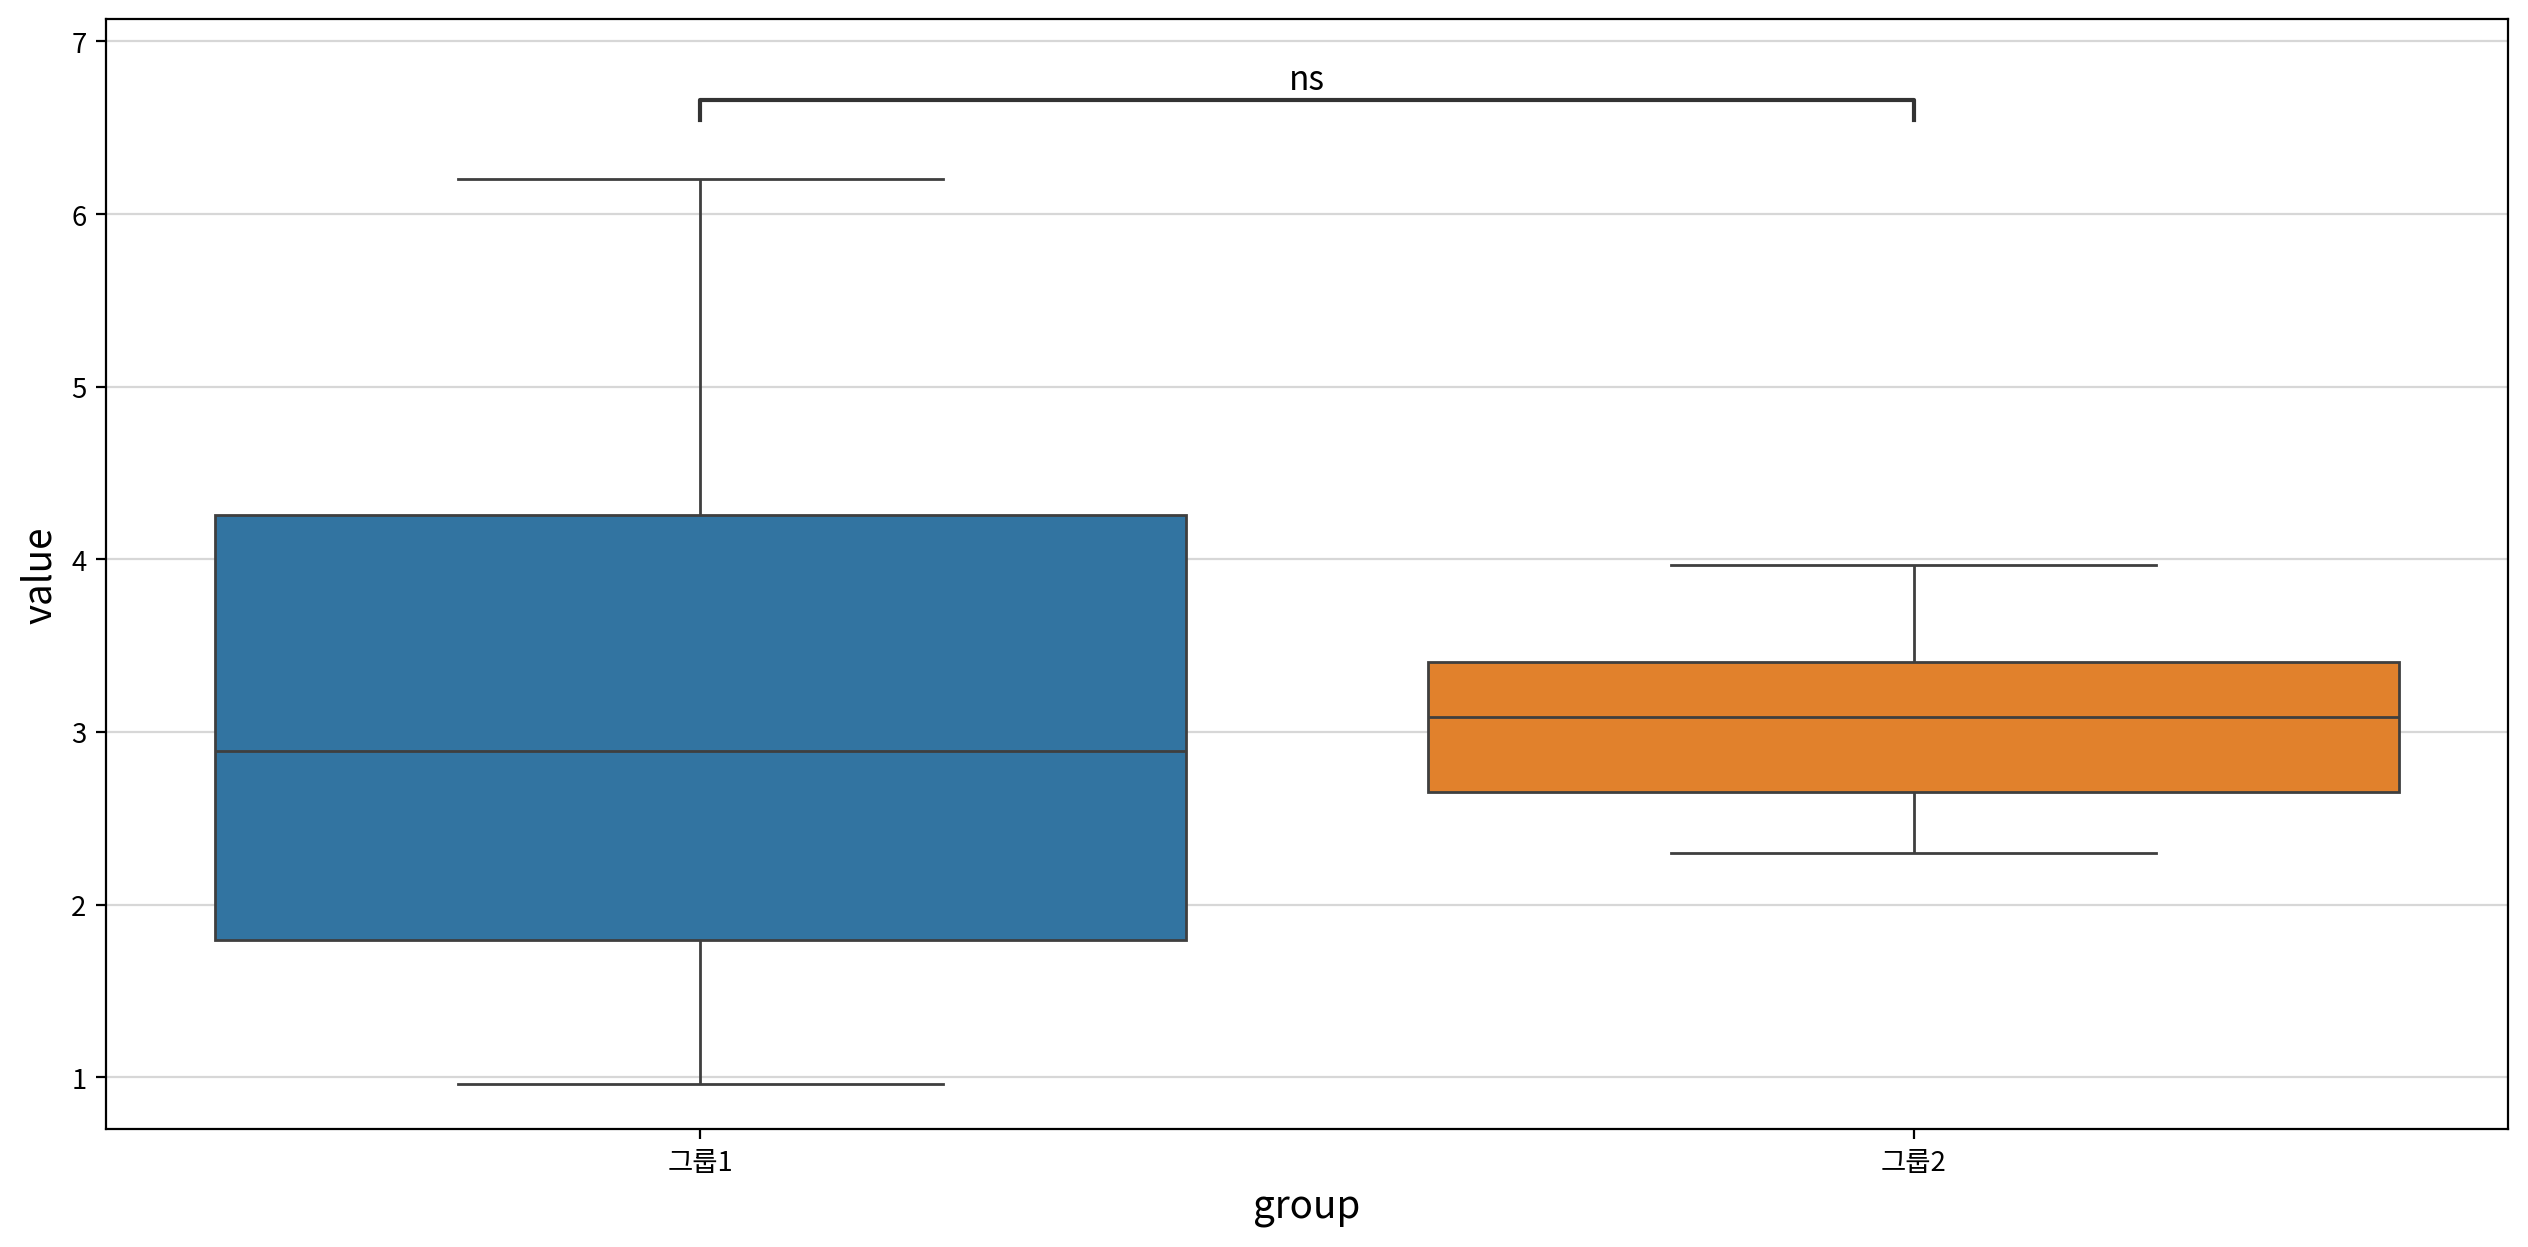

statistic  p-value  significant     result
test         alternative                                            
Welch t-test two-sided        0.163    0.874        False  그룹1 = 그룹2
             less             0.163    0.563        False  그룹1 ≥ 그룹2
             greater          0.163    0.437        False  그룹1 ≤ 그룹2

In [28]:
my_stats.test_independent(df2, "그룹1", "그룹2")

### 3. 두 종류의 진통제 효과 비교

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

약물A vs. 약물B: Mann-Whitney-Wilcoxon test two-sided, P_val:3.031e-03 U_stat=2.490e+02


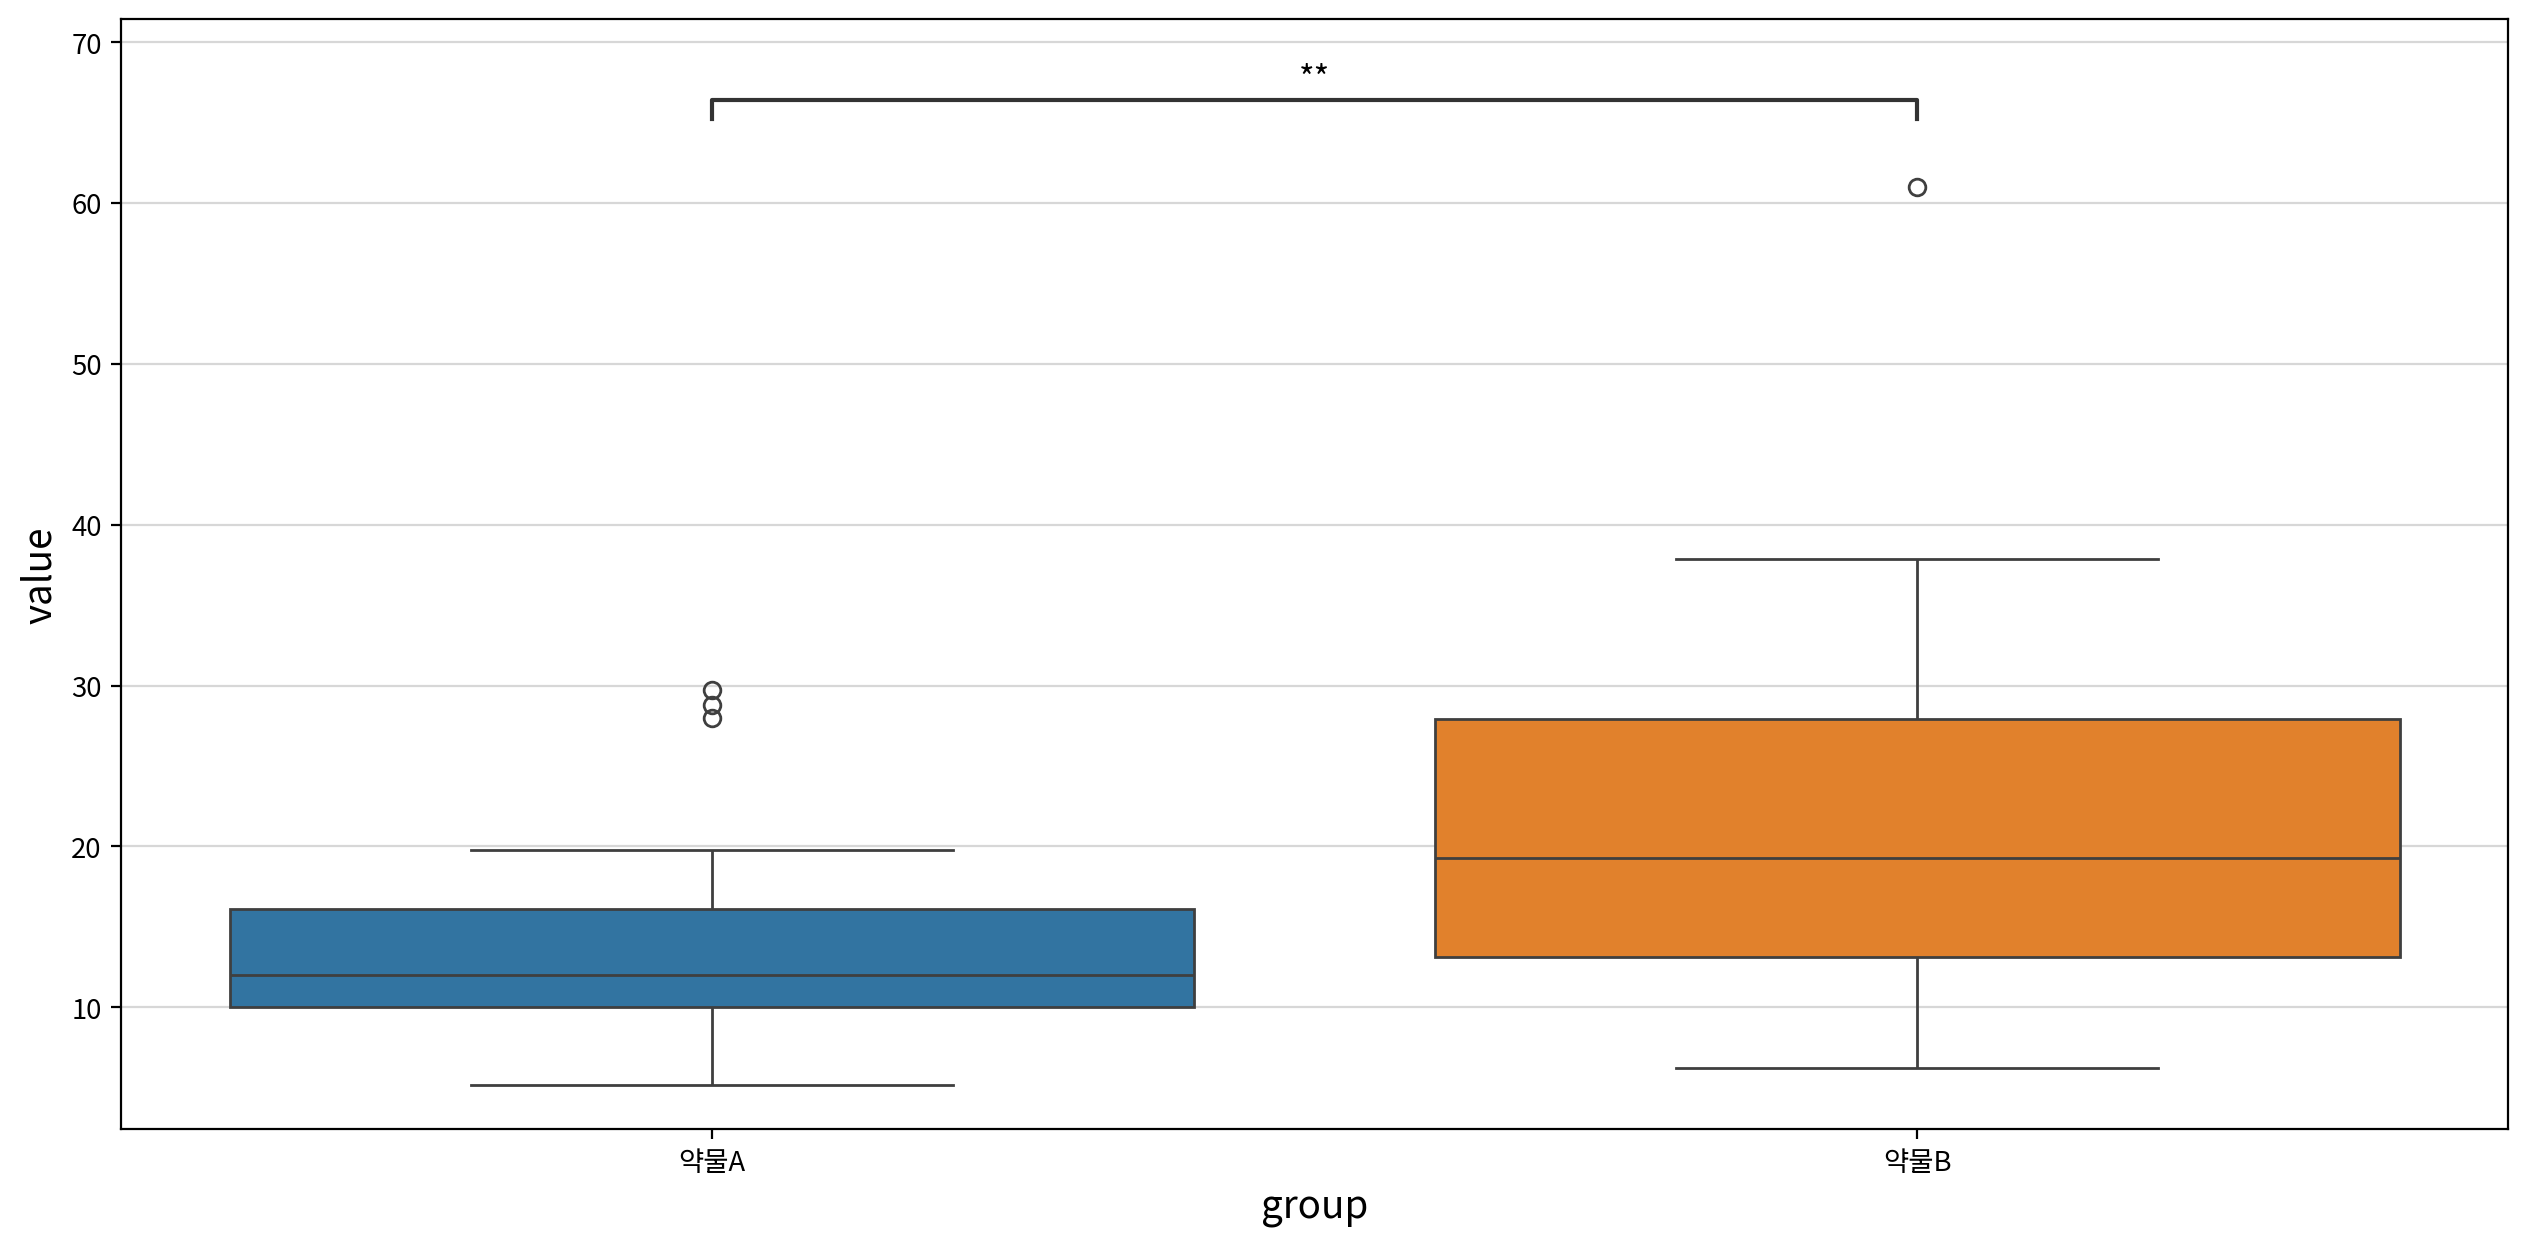

statistic  p-value  significant     result
test                alternative                                            
Mann-Whitney U test two-sided      249.000    0.003         True  약물A ≠ 약물B
                    less           249.000    0.002         True  약물A < 약물B
                    greater        249.000    0.999        False  약물A ≤ 약물B

In [29]:
my_stats.test_independent(df3_pivot, "약물A", "약물B")